# Kyle - afronding Data Mining ACLO

Dit notebook bevat een compact afmaakblok voor het project: volledige dagtabel met nul-dagen, corona-indicatoren, data dictionary, grafiekbeschrijvingen en modellen met lineaire regressie en KNN.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

base_path = Path('.')
print('Werkmap:', base_path.resolve())

Matplotlib is building the font cache; this may take a moment.


Werkmap: /mnt/data/work_project/Data-main-afgemaakt-Kyle


## 1. Dagtabel uitbreiden met ontbrekende kalenderdagen

De eerdere dagtabel bevatte alleen dagen waarop minimaal één check-in voorkwam. Voor corona is dat niet genoeg, omdat sluitingsdagen dan ontbreken. Daarom maken we hier een volledige datumreeks en vullen we ontbrekende dagen met 0 bezoeken.

In [2]:
df_checkin_per_dag = pd.read_csv('df_checkin_per_dag.csv')
df_checkin_per_dag['datum'] = pd.to_datetime(df_checkin_per_dag['datum'])

volledige_datumreeks = pd.DataFrame({
    'datum': pd.date_range(df_checkin_per_dag['datum'].min(), df_checkin_per_dag['datum'].max())
})

df_model_per_dag = volledige_datumreeks.merge(
    df_checkin_per_dag[['datum', 'aantal_bezoeken', 'unieke_bezoekers']],
    on='datum',
    how='left'
)

df_model_per_dag['aantal_bezoeken'] = df_model_per_dag['aantal_bezoeken'].fillna(0).astype(int)
df_model_per_dag['unieke_bezoekers'] = df_model_per_dag['unieke_bezoekers'].fillna(0).astype(int)

print('Aantal dagen in oorspronkelijke dagtabel:', len(df_checkin_per_dag))
print('Aantal dagen in volledige modeltabel:', len(df_model_per_dag))
print('Aantal dagen met 0 bezoeken:', (df_model_per_dag['aantal_bezoeken'] == 0).sum())

df_model_per_dag.head()

Aantal dagen in oorspronkelijke dagtabel: 1265
Aantal dagen in volledige modeltabel: 1584
Aantal dagen met 0 bezoeken: 319


,datum,aantal_bezoeken,unieke_bezoekers
0,2017-08-01,170,137
1,2017-08-02,140,117
2,2017-08-03,146,118
3,2017-08-04,157,128
4,2017-08-05,0,0


## 2. Datumkenmerken, academic calendar en corona toevoegen

In dit blok worden eerst datumkenmerken en de academic calendar gekoppeld. Daarna wordt de opgeschoonde corona-tabel van Kyle toegevoegd. Deze corona-tabel staat als `corona_dagvariabelen.csv` in dezelfde map als het notebook en is afgeleid van het bestand `corona.xlsx`. De bronnen staan in `corona_bronnen.csv` en in het tabblad **Bronnen** van `corona.xlsx`.

In [3]:
# Datumkenmerken
df_model_per_dag['jaar'] = df_model_per_dag['datum'].dt.year
df_model_per_dag['maand'] = df_model_per_dag['datum'].dt.month
df_model_per_dag['week'] = df_model_per_dag['datum'].dt.isocalendar().week.astype(int)
df_model_per_dag['weekdag_nummer'] = df_model_per_dag['datum'].dt.isocalendar().day.astype(int) # maandag = 1, zondag = 7
df_model_per_dag['weekdag'] = df_model_per_dag['datum'].dt.day_name()
df_model_per_dag['weekend'] = df_model_per_dag['weekdag_nummer'].isin([6, 7]).astype(int)

def bepaal_seizoen(maand):
    if maand in [12, 1, 2]:
        return 'Winter'
    elif maand in [3, 4, 5]:
        return 'Lente'
    elif maand in [6, 7, 8]:
        return 'Zomer'
    else:
        return 'Herfst'

df_model_per_dag['seizoen'] = df_model_per_dag['maand'].apply(bepaal_seizoen)
df_model_per_dag['seizoen_nummer'] = df_model_per_dag['seizoen'].map({
    'Winter': 1, 'Lente': 2, 'Zomer': 3, 'Herfst': 4
})

# Academic calendar koppelen
df_academic = pd.read_excel('Academic calendar.xlsx')
df_academic.columns = df_academic.columns.str.strip().str.lower().str.replace(' ', '_')
df_academic['datum'] = pd.to_datetime(df_academic['datum'])

for kolom in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
    df_academic[kolom] = (
        df_academic[kolom].astype(str).str.lower().str.strip().eq('x')
    ).astype(int)

df_model_per_dag = df_model_per_dag.drop(columns=['weekend']).merge(
    df_academic[['datum', 'feestdag', 'vakantie', 'tentamenperiode', 'weekend']],
    on='datum',
    how='left'
)

for kolom in ['feestdag', 'vakantie', 'tentamenperiode', 'weekend']:
    df_model_per_dag[kolom] = df_model_per_dag[kolom].fillna(0).astype(int)

df_model_per_dag.head()

,datum,aantal_bezoeken,unieke_bezoekers,jaar,maand,week,weekdag_nummer,weekdag,seizoen,seizoen_nummer,feestdag,vakantie,tentamenperiode,weekend
0,2017-08-01,170,137,2017,8,31,2,Tuesday,Zomer,3,0,1,0,0
1,2017-08-02,140,117,2017,8,31,3,Wednesday,Zomer,3,0,1,0,0
2,2017-08-03,146,118,2017,8,31,4,Thursday,Zomer,3,0,1,0,0
3,2017-08-04,157,128,2017,8,31,5,Friday,Zomer,3,0,1,0,0
4,2017-08-05,0,0,2017,8,31,6,Saturday,Zomer,3,0,1,0,1


In [4]:
# Corona-indeling uit de opgeschoonde externe-bronnentabel
# Dit vervangt de eerdere handmatige functie met corona-fases.
# Het bestand corona_dagvariabelen.csv is gemaakt uit corona.xlsx.

corona_path = Path('corona_dagvariabelen.csv')

if not corona_path.exists():
    raise FileNotFoundError(
        "corona_dagvariabelen.csv niet gevonden. Zet dit bestand in dezelfde map als dit notebook. "
        "Het bestand is de CSV-export van de opgeschoonde corona.xlsx."
    )

df_corona = pd.read_csv(corona_path)
df_corona.columns = df_corona.columns.str.strip().str.lower().str.replace(' ', '_')
df_corona['datum'] = pd.to_datetime(df_corona['datum'])

# Numerieke kolommen netjes omzetten
for kolom in ['corona_intensity', 'sportschool_gesloten', 'groepslessen_verboden']:
    df_corona[kolom] = pd.to_numeric(df_corona[kolom], errors='coerce').fillna(0).astype(int)

df_corona['max_personen_per_ruimte'] = pd.to_numeric(
    df_corona['max_personen_per_ruimte'], errors='coerce'
)

# Corona-informatie koppelen aan de modeltabel
corona_kolommen = [
    'datum',
    'status_sportschool_model',
    'corona_intensity',
    'sportschool_gesloten',
    'max_personen_per_ruimte',
    'groepslessen_verboden'
]

df_model_per_dag = df_model_per_dag.merge(
    df_corona[corona_kolommen],
    on='datum',
    how='left'
)

# Voor datums buiten de corona-tabel: aannemen dat er geen coronabeperking is
# In deze dataset loopt de corona-tabel van 2017-08-01 t/m 2021-12-01.
df_model_per_dag['status_sportschool_model'] = df_model_per_dag['status_sportschool_model'].fillna('Open')
for kolom in ['corona_intensity', 'sportschool_gesloten', 'groepslessen_verboden']:
    df_model_per_dag[kolom] = df_model_per_dag[kolom].fillna(0).astype(int)

# Extra alias-kolommen, zodat latere grafieken/teksten leesbaar blijven
# corona_fase = tekstuele status uit jouw corona.xlsx
# corona_gesloten = binaire sluitingsindicator
# corona_beperkt = wel coronabeperking, maar niet volledig gesloten
# corona_fase_nummer = intensiteit: 0=open, 1=beperkt, 2=zeer beperkt, 3=gesloten

df_model_per_dag['corona_fase'] = df_model_per_dag['status_sportschool_model']
df_model_per_dag['corona_gesloten'] = df_model_per_dag['sportschool_gesloten']
df_model_per_dag['corona_beperkt'] = (
    (df_model_per_dag['corona_intensity'] > 0) &
    (df_model_per_dag['sportschool_gesloten'] == 0)
).astype(int)
df_model_per_dag['corona_fase_nummer'] = df_model_per_dag['corona_intensity']

# Controle: samenvatting per corona-status
df_model_per_dag.groupby('status_sportschool_model').agg(
    dagen=('datum', 'count'),
    totaal_bezoeken=('aantal_bezoeken', 'sum'),
    gemiddeld_per_dag=('aantal_bezoeken', 'mean'),
    gemiddeld_corona_intensity=('corona_intensity', 'mean')
).round(1).sort_values('gemiddeld_corona_intensity')

,dagen,totaal_bezoeken,gemiddeld_per_dag,gemiddeld_corona_intensity
status_sportschool_model,,,,
Open,954,285572,299.3,0.0
Beperkt,296,38910,131.5,1.0
Zeer beperkt,6,1100,183.3,2.0
"Zeer beperkt, max. 2 personen",40,7042,176.0,2.0
"Zeer beperkt, max. 4 personen",21,3562,169.6,2.0
Gesloten,267,618,2.3,3.0


## 3. Weerdata toevoegen

In [5]:
df_weer = pd.read_csv('KNMI weerdata Eelde 2017-2021.csv', decimal='.', sep=';')
df_weer.columns = ['station', 'datum', 'gem_windsnelheid', 'max_windsnelheid', 'min_windsnelheid',
                   'gem_temperatuur', 'min_temperatuur', 'max_temperatuur', 'duur_neerslag', 'som_neerslag']

df_weer['datum'] = pd.to_datetime(df_weer['datum'], format='%Y%m%d')

kolommen_keer_tien = ['gem_windsnelheid', 'max_windsnelheid', 'min_windsnelheid',
                      'gem_temperatuur', 'min_temperatuur', 'max_temperatuur',
                      'duur_neerslag', 'som_neerslag']

df_weer[kolommen_keer_tien] = df_weer[kolommen_keer_tien] / 10
df_weer['som_neerslag'] = df_weer['som_neerslag'].replace(-0.1, 0.025)

def bepaal_windkracht(windsnelheid):
    grenzen = [0.2, 1.5, 3.3, 5.4, 7.9, 10.7, 13.8, 17.1, 20.7, 24.4, 28.4, 32.6]
    for i, grens in enumerate(grenzen):
        if windsnelheid <= grens:
            return i
    return 12

df_weer['gem_windkracht'] = df_weer['gem_windsnelheid'].apply(bepaal_windkracht)

df_model_per_dag = df_model_per_dag.merge(
    df_weer[['datum', 'max_temperatuur', 'som_neerslag', 'gem_windkracht']],
    on='datum',
    how='left'
)

df_model_per_dag.to_csv('df_model_per_dag_met_corona.csv', index=False)
df_model_per_dag.head()

,datum,aantal_bezoeken,unieke_bezoekers,jaar,maand,week,weekdag_nummer,weekdag,seizoen,seizoen_nummer,feestdag,vakantie,tentamenperiode,weekend,status_sportschool_model,corona_intensity,sportschool_gesloten,max_personen_per_ruimte,groepslessen_verboden,corona_fase,corona_gesloten,corona_beperkt,corona_fase_nummer,max_temperatuur,som_neerslag,gem_windkracht
0,2017-08-01,170,137,2017,8,31,2,Tuesday,Zomer,3,0,1,0,0,Open,0,0,NaN,0,Open,0,0,0,22.2,0.000,2
1,2017-08-02,140,117,2017,8,31,3,Wednesday,Zomer,3,0,1,0,0,Open,0,0,NaN,0,Open,0,0,0,22.3,0.025,3
2,2017-08-03,146,118,2017,8,31,4,Thursday,Zomer,3,0,1,0,0,Open,0,0,NaN,0,Open,0,0,0,21.7,3.700,4
3,2017-08-04,157,128,2017,8,31,5,Friday,Zomer,3,0,1,0,0,Open,0,0,NaN,0,Open,0,0,0,21.3,1.900,4
4,2017-08-05,0,0,2017,8,31,6,Saturday,Zomer,3,0,1,0,1,Open,0,0,NaN,0,Open,0,0,0,20.5,0.000,3


## 4. Data dictionary

In [6]:
data_dictionary = pd.DataFrame([
    ['datum', 'datetime', 'Datum waarop de bezoeken zijn geaggregeerd.', 'Onafhankelijke variabele / tijdsas'],
    ['aantal_bezoeken', 'integer', 'Aantal fitness-check-ins op die datum. Mogelijke dubbele check-ins binnen 60 seconden zijn niet meegeteld.', 'Afhankelijke variabele / target'],
    ['unieke_bezoekers', 'integer', 'Aantal unieke klantnummers dat op die datum heeft ingecheckt.', 'Controlevariabele / beschrijvend'],
    ['jaar', 'integer', 'Kalenderjaar van de datum.', 'Onafhankelijke variabele'],
    ['maand', 'integer', 'Kalendermaand van de datum, 1 t/m 12.', 'Onafhankelijke variabele'],
    ['week', 'integer', 'ISO-weeknummer van de datum.', 'Onafhankelijke variabele'],
    ['weekdag_nummer', 'integer', 'ISO-weekdag: maandag = 1, zondag = 7.', 'Onafhankelijke variabele'],
    ['weekdag', 'categorisch', 'Naam van de weekdag.', 'Beschrijvend / visualisatie'],
    ['weekend', 'binair', '1 als de datum in het weekend valt, anders 0.', 'Onafhankelijke variabele'],
    ['seizoen', 'categorisch', 'Winter, lente, zomer of herfst op basis van de maand.', 'Beschrijvend / visualisatie'],
    ['seizoen_nummer', 'integer', 'Numerieke omzetting van seizoen voor modellering.', 'Onafhankelijke variabele'],
    ['feestdag', 'binair', '1 als de datum volgens de academic calendar een feestdag is, anders 0.', 'Onafhankelijke variabele'],
    ['vakantie', 'binair', '1 als de datum volgens de academic calendar binnen een vakantieperiode valt, anders 0.', 'Onafhankelijke variabele'],
    ['tentamenperiode', 'binair', '1 als de datum volgens de academic calendar binnen een tentamenperiode valt, anders 0.', 'Onafhankelijke variabele'],
    ['status_sportschool_model', 'categorisch', 'Corona-status van de sportschool per datum volgens de opgeschoonde externe-bronnentabel.', 'Extra verklarende variabele / beschrijvend'],
    ['corona_intensity', 'integer', 'Numerieke corona-intensiteit: 0 = open, 1 = beperkt, 2 = zeer beperkt, 3 = gesloten.', 'Onafhankelijke variabele'],
    ['sportschool_gesloten', 'binair', '1 als sportscholen volgens de corona-indeling gesloten waren, anders 0.', 'Onafhankelijke variabele'],
    ['max_personen_per_ruimte', 'float/integer', 'Maximumaantal personen per ruimte als de externe bron een concreet aantal noemt. Leeg als geen concreet maximum is gebruikt.', 'Beschrijvend / corona-context'],
    ['groepslessen_verboden', 'binair', '1 als groepslessen volgens de corona-indeling verboden waren, anders 0.', 'Onafhankelijke variabele'],
    ['corona_fase', 'categorisch', 'Alias van status_sportschool_model, gebruikt voor grafieken en samenvattingen.', 'Beschrijvend / visualisatie'],
    ['corona_gesloten', 'binair', 'Alias van sportschool_gesloten.', 'Onafhankelijke variabele'],
    ['corona_beperkt', 'binair', '1 als er coronabeperkingen waren, maar de sportschool niet volledig gesloten was.', 'Onafhankelijke variabele'],
    ['corona_fase_nummer', 'integer', 'Alias van corona_intensity voor eenvoudige modellen.', 'Onafhankelijke variabele'],
    ['max_temperatuur', 'float', 'Maximumtemperatuur per dag in graden Celsius, KNMI-station Eelde.', 'Onafhankelijke variabele'],
    ['som_neerslag', 'float', 'Etmaalsom neerslag in millimeters, KNMI-station Eelde.', 'Onafhankelijke variabele'],
    ['gem_windkracht', 'integer', 'Gemiddelde windkracht volgens Beaufortschaal, afgeleid van gemiddelde windsnelheid.', 'Onafhankelijke variabele']
], columns=['Variabele', 'Type', 'Betekenis', 'Rol in analyse/model'])

data_dictionary.to_csv('data_dictionary_modeltabel.csv', index=False)
data_dictionary

,Variabele,Type,Betekenis,Rol in analyse/model
0,datum,datetime,Datum waarop de bezoeken zijn geaggregeerd.,Onafhankelijke variabele / tijdsas
1,aantal_bezoeken,integer,Aantal fitness-check-ins op die datum. Mogelij...,Afhankelijke variabele / target
2,unieke_bezoekers,integer,Aantal unieke klantnummers dat op die datum he...,Controlevariabele / beschrijvend
3,jaar,integer,Kalenderjaar van de datum.,Onafhankelijke variabele
4,maand,integer,"Kalendermaand van de datum, 1 t/m 12.",Onafhankelijke variabele
5,week,integer,ISO-weeknummer van de datum.,Onafhankelijke variabele
6,weekdag_nummer,integer,"ISO-weekdag: maandag = 1, zondag = 7.",Onafhankelijke variabele
7,weekdag,categorisch,Naam van de weekdag.,Beschrijvend / visualisatie
8,weekend,binair,"1 als de datum in het weekend valt, anders 0.",Onafhankelijke variabele
9,seizoen,categorisch,"Winter, lente, zomer of herfst op basis van de...",Beschrijvend / visualisatie


## 5. Grafieken en kerncijfers

In [7]:
print('Gemiddeld aantal bezoeken per dag:', round(df_model_per_dag['aantal_bezoeken'].mean(), 1))
print('Mediaan aantal bezoeken per dag:', round(df_model_per_dag['aantal_bezoeken'].median(), 1))
print('Maximum aantal bezoeken op één dag:', int(df_model_per_dag['aantal_bezoeken'].max()))
print('Aantal dagen met nul bezoeken:', int((df_model_per_dag['aantal_bezoeken'] == 0).sum()))

print('\nGemiddelde per weekdag:')
display(df_model_per_dag.groupby('weekdag')['aantal_bezoeken'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).round(1))

print('\nGemiddelde per maand:')
display(df_model_per_dag.groupby('maand')['aantal_bezoeken'].mean().round(1))

print('\nGemiddelde per seizoen:')
display(df_model_per_dag.groupby('seizoen')['aantal_bezoeken'].mean().reindex(['Winter','Lente','Zomer','Herfst']).round(1))

Gemiddeld aantal bezoeken per dag: 212.6
Mediaan aantal bezoeken per dag: 191.0
Maximum aantal bezoeken op één dag: 645
Aantal dagen met nul bezoeken: 319

Gemiddelde per weekdag:


weekdag
Monday       282.3
Tuesday      267.7
Wednesday    260.6
Thursday     230.9
Friday       211.6
Saturday     121.6
Sunday       113.2
Name: aantal_bezoeken, dtype: float64


Gemiddelde per maand:


maand
1     235.5
2     296.8
3     234.0
4     167.4
5     195.2
6     191.6
7     101.7
8      95.4
9     218.6
10    298.7
11    300.1
12    210.1
Name: aantal_bezoeken, dtype: float64


Gemiddelde per seizoen:


seizoen
Winter    245.9
Lente     199.2
Zomer     126.3
Herfst    272.7
Name: aantal_bezoeken, dtype: float64

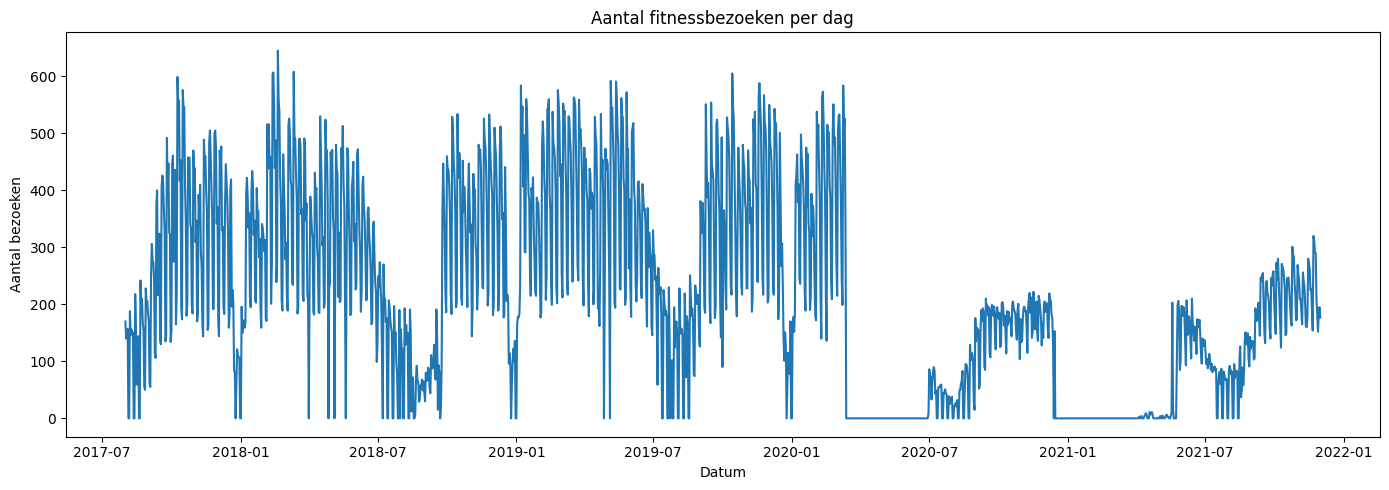

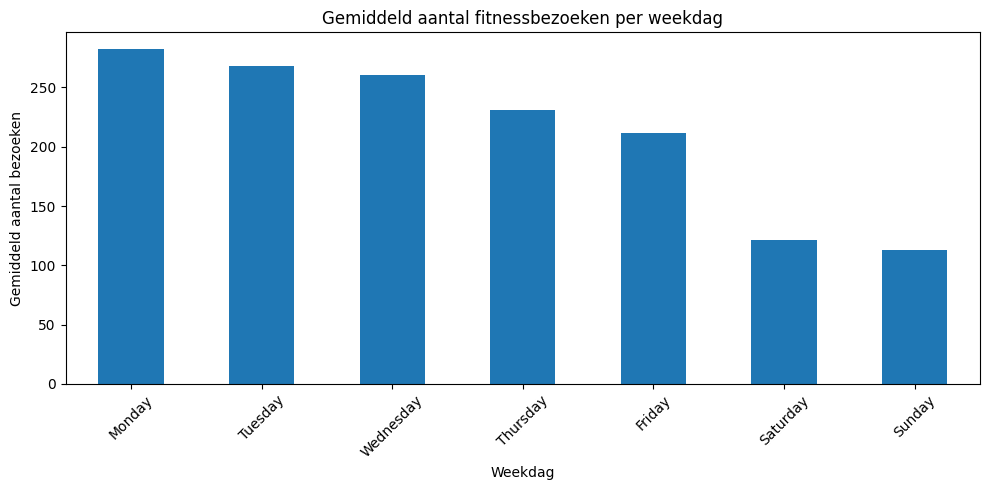

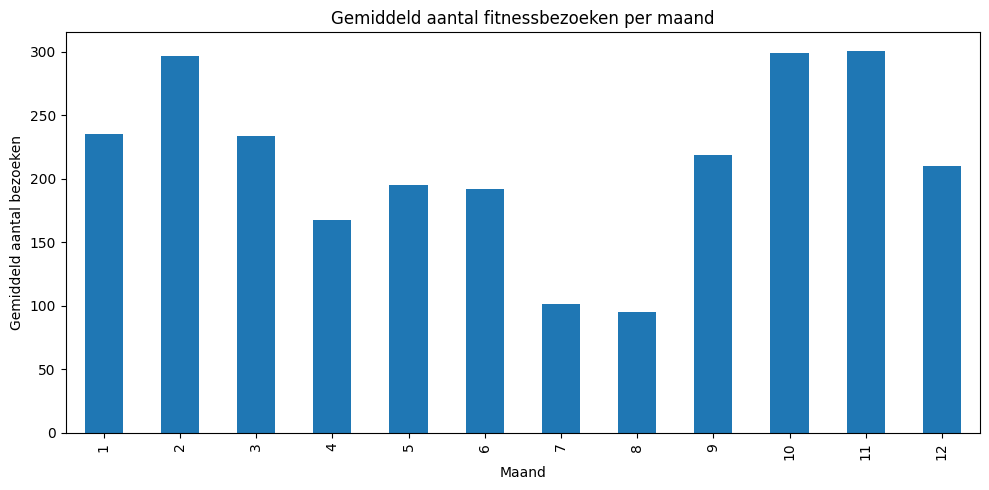

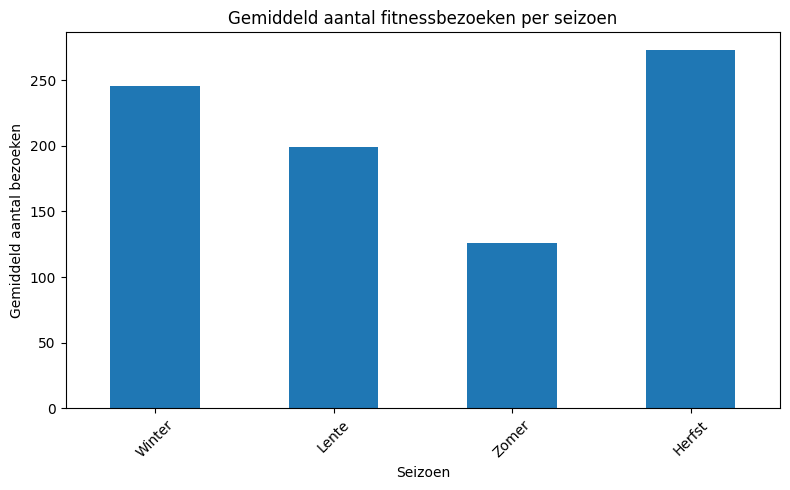

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df_model_per_dag['datum'], df_model_per_dag['aantal_bezoeken'])
plt.title('Aantal fitnessbezoeken per dag')
plt.xlabel('Datum')
plt.ylabel('Aantal bezoeken')
plt.tight_layout()
plt.show()

weekdag_volgorde = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
gemiddelde_per_weekdag = df_model_per_dag.groupby('weekdag')['aantal_bezoeken'].mean().reindex(weekdag_volgorde)
plt.figure(figsize=(10, 5))
gemiddelde_per_weekdag.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per weekdag')
plt.xlabel('Weekdag')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

gemiddelde_per_maand = df_model_per_dag.groupby('maand')['aantal_bezoeken'].mean()
plt.figure(figsize=(10, 5))
gemiddelde_per_maand.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per maand')
plt.xlabel('Maand')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.tight_layout()
plt.show()

gemiddelde_per_seizoen = df_model_per_dag.groupby('seizoen')['aantal_bezoeken'].mean().reindex(['Winter','Lente','Zomer','Herfst'])
plt.figure(figsize=(8, 5))
gemiddelde_per_seizoen.plot(kind='bar')
plt.title('Gemiddeld aantal fitnessbezoeken per seizoen')
plt.xlabel('Seizoen')
plt.ylabel('Gemiddeld aantal bezoeken')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Lineaire regressie en KNN

Omdat de target `aantal_bezoeken` een getal is, is dit een regressieprobleem. Daarom gebruiken we lineaire regressie als uitlegbaar basismodel en KNN Regressor als eenvoudig niet-lineair alternatief.

In [9]:
features = [
    'weekdag_nummer', 'weekend', 'vakantie', 'tentamenperiode', 'maand', 'seizoen_nummer',
    'max_temperatuur', 'som_neerslag', 'gem_windkracht',
    'corona_intensity', 'sportschool_gesloten', 'groepslessen_verboden'
]

# Alleen rijen gebruiken waarvoor alle model-features beschikbaar zijn.
# max_personen_per_ruimte staat bewust niet in de features, omdat deze vaak leeg is wanneer er geen concreet maximum gold.
model_data = df_model_per_dag[features + ['aantal_bezoeken']].dropna().copy()

X = model_data[features]
y = model_data['aantal_bezoeken']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=6)

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    pred_train = model.predict(X_train)
    return {
        'model': name,
        'R2_test': r2_score(y_test, pred_test),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, pred_test)),
        'MAE_test': mean_absolute_error(y_test, pred_test),
        'R2_train': r2_score(y_train, pred_train),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, pred_train)),
        'MAE_train': mean_absolute_error(y_train, pred_train)
    }

models = [
    ('Lineaire regressie', LinearRegression()),
    ('KNN regressie k=5', Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5))])),
    ('KNN regressie k=11', Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=11))]))
]

resultaten = pd.DataFrame([evaluate_model(name, model) for name, model in models])
resultaten.round(3)

,model,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,Lineaire regressie,0.768,84.869,65.890,0.760,83.156,63.763
1,KNN regressie k=5,0.860,65.865,44.406,0.896,54.765,35.044
2,KNN regressie k=11,0.851,67.988,44.835,0.861,63.415,40.947


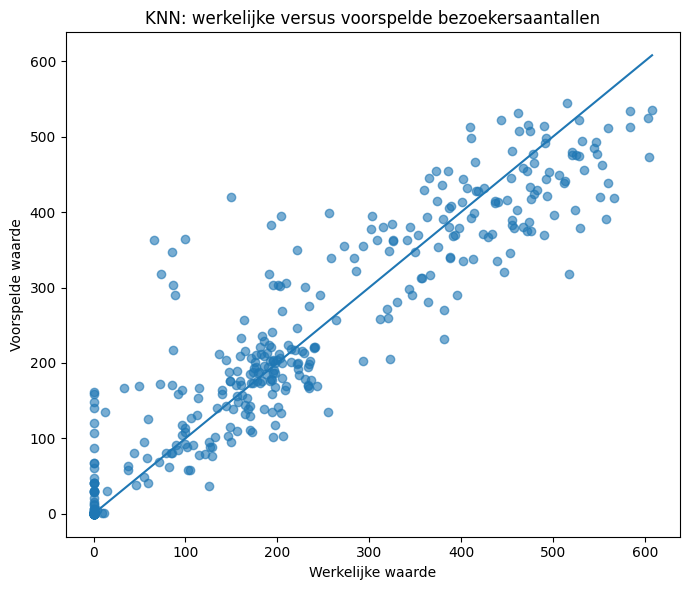

In [10]:
# Visualisatie: voorspeld versus werkelijk voor het beste eenvoudige model
beste_model = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5))])
beste_model.fit(X_train, y_train)
y_pred = beste_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, y_test.max()], [0, y_test.max()])
plt.title('KNN: werkelijke versus voorspelde bezoekersaantallen')
plt.xlabel('Werkelijke waarde')
plt.ylabel('Voorspelde waarde')
plt.tight_layout()
plt.show()

## 7. Korte conclusie voor in het notebook

De modellen laten zien dat datumkenmerken, vakantieperiodes, weersinformatie en corona-indicatoren samen een redelijk deel van de variatie in het aantal fitnessbezoeken verklaren. Lineaire regressie is goed uitlegbaar, maar KNN kan beter omgaan met niet-lineaire patronen, zoals het verschil tussen normale weken, weekenden en coronaperiodes. De coronavariabelen komen uit de opgeschoonde externe-bronnentabel (`corona.xlsx` / `corona_dagvariabelen.csv`). De voorspelling is daarom bruikbaar om globale druktepatronen te begrijpen, maar niet om exact per dag het aantal bezoekers te voorspellen.